# Практика: Метод опорных векторов (SVM)

## Что вы сделаете

В этом ноутбуке вы:

1. Загрузите датасет Breast Cancer и проведёте базовый EDA;
2. Обучите **LinearSVC** — быстрый линейный SVM;
3. Исследуете влияние **масштабирования признаков** на качество;
4. Подберёте гиперпараметры (**C**, **kernel**, **gamma**) через `GridSearchCV`;
5. Визуализируете **границу решений** на двух признаках;
6. Проанализируете **ошибки** модели и опорные векторы;
7. Сравните линейный и RBF SVM.

**Датасет:** [Breast Cancer Wisconsin](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_breast_cancer.html) — бинарная классификация (злокачественная / доброкачественная опухоль), 569 примеров, 30 числовых признаков.

---
**Как работать:** ячейки с `# YOUR CODE HERE` нужно заполнить самостоятельно. Там же указаны подсказки и ожидаемые результаты.

## Коротко о теории

### Разделяющая гиперплоскость и margin

SVM ищет гиперплоскость $\mathbf{w}^\top \mathbf{x} + b = 0$, максимизирующую зазор (margin):

$$\text{margin} = \frac{2}{\|\mathbf{w}\|}$$

Это эквивалентно задаче:

$$\min_{\mathbf{w},b}\; \frac{1}{2}\|\mathbf{w}\|^2 + C\sum_i \xi_i \quad \text{при} \quad y_i(\mathbf{w}^\top\mathbf{x}_i + b) \geq 1 - \xi_i$$

### Ядровой трюк

RBF ядро: $K(\mathbf{x}_i, \mathbf{x}_j) = \exp(-\gamma\|\mathbf{x}_i - \mathbf{x}_j\|^2)$ — позволяет строить нелинейные границы без явного перехода в высокомерное пространство.

### Ключевые параметры

| Параметр | Влияние |
|---|---|
| `C` большой | Узкий margin, мало ошибок на train, риск переобучения |
| `C` малый | Широкий margin, допускает ошибки, лучше обобщение |
| `gamma` большой | Сложная граница, переобучение |
| `gamma` малый | Гладкая граница, недообучение |

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC, LinearSVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, ConfusionMatrixDisplay
)

np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid')
print('Импорты выполнены успешно!')

Импорты выполнены успешно!


In [ ]:
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns = data.feature_names)
y = pd.Series(data.target, name = 'target')

print('Размер датасета:', X.shape)
print('Классы:', data.target_names)
print('Распределение классов:')
print(y.value_counts())

display(X.head())

Размер датасета: (569, 30)
Классы: ['malignant' 'benign']
Распределение классов:
target
1    357
0    212
Name: count, dtype: int64


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


Пропуски по признакам:


np.int64(0)


Базовая статистика первых 5 признаков:


,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127,3.524,6.981,11.700,13.370,15.780,28.110
mean texture,569.0,19.290,4.301,9.710,16.170,18.840,21.800,39.280
mean perimeter,569.0,91.969,24.299,43.790,75.170,86.240,104.100,188.500
mean area,569.0,654.889,351.914,143.500,420.300,551.100,782.700,2501.000
mean smoothness,569.0,0.096,0.014,0.053,0.086,0.096,0.105,0.163


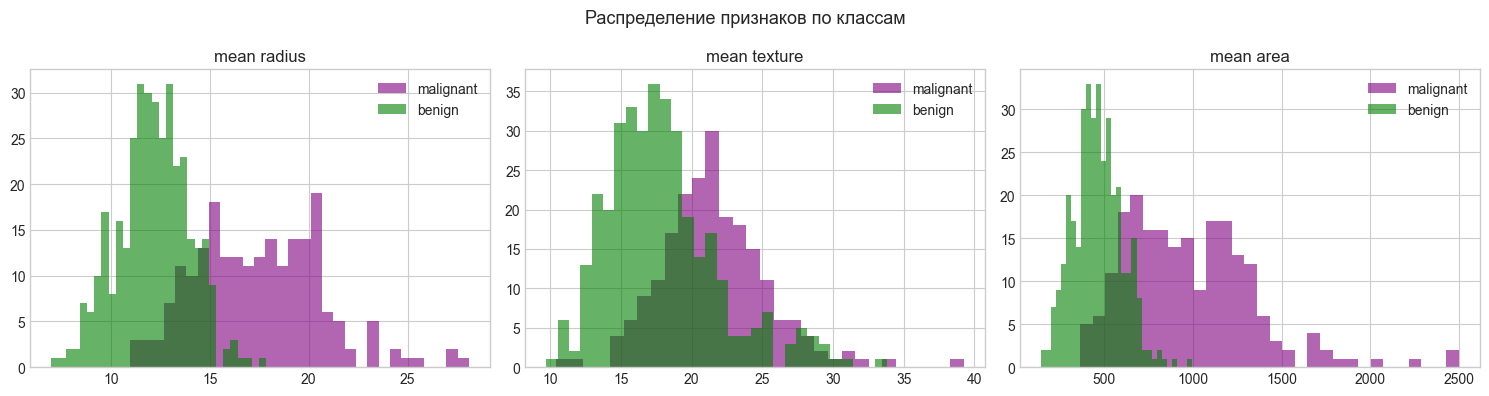

In [ ]:
# EDA: базовая статистика и распределения
print('Пропуски по признакам:')
display(X.isna().sum().sum())

print('\nБазовая статистика первых 5 признаков:')
display(X.iloc[:, :5].describe().T.round(3))

# Распределение нескольких признаков по классам
fig, axes = plt.subplots(1, 3, figsize = (15, 4))
features_to_plot = ['mean radius', 'mean texture', 'mean area']

for ax, feat in zip(axes, features_to_plot):
    for cls, label, color in [(0, 'malignant', 'purple'), (1, 'benign', 'green')]:
        ax.hist(X.loc[y == cls, feat], bins = 30, alpha = 0.6, label = label, color = color)
    ax.set_title(feat)
    ax.legend()

plt.suptitle('Распределение признаков по классам', fontsize=13)
plt.tight_layout()
plt.show()

## Шаг 1. Разделение данных

Разбейте выборку на train и test в соотношении 80/20, зафиксировав `random_state=42`.

Убедитесь, что стратификация сохраняет баланс классов: используйте `stratify=y`.

In [ ]:
# Делим 80/20, stratify сохраняет пропорцию классов
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, stratify = y, random_state = 42
)
print('Train shape:', X_train.shape)
print('Test shape:', X_test.shape)
print('Баланс классов в train:', y_train.value_counts().to_dict())
print('Баланс классов в test:', y_test.value_counts().to_dict())


Train shape: (455, 30)
Test shape: (114, 30)
Баланс классов в train: {1: 285, 0: 170}
Баланс классов в test: {1: 72, 0: 42}


## Шаг 2. SVM без масштабирования — что будет?

Сначала обучим SVC с RBF ядром **без нормализации** и зафиксируем качество. Потом сравним с нормализованным вариантом.

Используйте `SVC(kernel='rbf', C=1.0, random_state=42)`.

In [ ]:
# SVM БЕЗ масштабирования — специально чтобы увидеть разницу
svm_no_scale = SVC(kernel = 'rbf', C = 1.0, random_state = 42)
svm_no_scale.fit(X_train, y_train)
y_pred_no_scale = svm_no_scale.predict(X_test)

acc_no = accuracy_score(y_test, y_pred_no_scale)
f1_no  = f1_score(y_test, y_pred_no_scale)
print('Accuracy без масштабирования:', round(acc_no, 4))
print('F1 без масштабирования:', round(f1_no, 4))


Accuracy без масштабирования: 0.9298
F1 без масштабирования: 0.9459


## Шаг 3. SVM с масштабированием через Pipeline

Теперь постройте Pipeline:
```
StandardScaler → SVC(kernel='rbf', C=1.0, random_state=42)
```

Сравните результат с шагом 2. Ожидаемое улучшение: заметный прирост accuracy и F1.

In [ ]:
# Pipeline: сначала масштабируем, потом SVM
# Pipeline гарантирует что scaler.fit только на train — нет leakage
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel = 'rbf', C = 1.0, random_state = 42))
])
pipe.fit(X_train, y_train)
y_pred_scaled = pipe.predict(X_test)

acc_sc = accuracy_score(y_test, y_pred_scaled)
f1_sc  = f1_score(y_test, y_pred_scaled)
print('Accuracy С масштабированием:', round(acc_sc, 4))
print('F1 С масштабированием:', round(f1_sc, 4))
print('\nКлассификационный отчёт:')
print(classification_report(y_test, y_pred_scaled, target_names = data.target_names))


Accuracy С масштабированием: 0.9825
F1 С масштабированием: 0.9861

Классификационный отчёт:
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



## Шаг 4. Подбор гиперпараметров через GridSearchCV

Используйте `GridSearchCV` для перебора следующей сетки параметров:

```python
param_grid = {
    'svm__C':      [0.01, 0.1, 1, 10, 100],
    'svm__kernel': ['linear', 'rbf'],
    'svm__gamma':  ['scale', 0.01, 0.1],
}
```

Параметры поиска: `cv=5`, `scoring='f1'`.

**Важно:** используйте тот же Pipeline со скейлером, чтобы избежать data leakage!

In [ ]:
param_grid = {
    'svm__C': [0.01, 0.1, 1, 10, 100],
    'svm__kernel': ['linear', 'rbf'],
    'svm__gamma': ['scale', 0.01, 0.1],
}

# Базовый Pipeline для GridSearch
base_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('svm',    SVC(random_state=42))
])

# GridSearchCV перебирает все комбинации через кросс-валидацию
search = GridSearchCV(
    base_pipe, param_grid,
    cv = 5, scoring = 'f1',
    n_jobs = -1, verbose = 0
)
search.fit(X_train, y_train)

print('Лучшие параметры:', search.best_params_)
print('CV F1 (best):', round(search.best_score_, 4))


Лучшие параметры: {'svm__C': 10, 'svm__gamma': 0.01, 'svm__kernel': 'rbf'}
CV F1 (best): 0.9844


In [ ]:
best_model = search.best_estimator_

y_pred_best = best_model.predict(X_test)

print('Test accuracy (best):', round(accuracy_score(y_test, y_pred_best), 4))
print('Test F1 (best):', round(f1_score(y_test, y_pred_best), 4))
print(classification_report(y_test, y_pred_best, target_names = data.target_names))


Test accuracy (best): 0.9825
Test F1 (best): 0.9861
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



## Шаг 5. Confusion Matrix

Визуализируйте матрицу ошибок для лучшей модели.

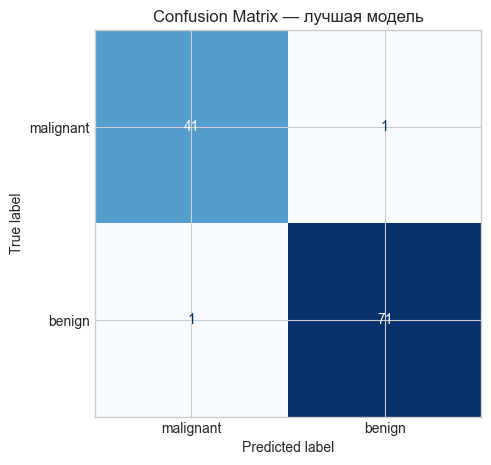

In [ ]:
fig, ax = plt.subplots(figsize = (5, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_best,
    display_labels = data.target_names,
    ax = ax,
    colorbar = False,
    cmap = 'Blues'
)
ax.set_title('Confusion Matrix — лучшая модель')
plt.tight_layout()
plt.show()


## Шаг 6. Граница решений на двух признаках

Для визуализации возьмём два признака: `'mean radius'` и `'mean texture'`.

Обучите SVM с RBF ядром и лучшими найденными `C` и `gamma` на этих двух признаках, затем визуализируйте границу решений.

Ниже дана вспомогательная функция — вам нужно её вызвать.

In [ ]:
def plot_decision_boundary(model, X_2d, y, title='Граница решений SVM'):
    """Визуализирует границу решений обученной модели на двумерных данных."""
    h = 0.05
    x_min, x_max = X_2d[:, 0].min() - 0.5, X_2d[:, 0].max() + 0.5
    y_min, y_max = X_2d[:, 1].min() - 0.5, X_2d[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                          np.arange(y_min, y_max, h))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.figure(figsize = (8, 6))
    plt.contourf(xx, yy, Z, alpha = 0.25,
                 cmap=mcolors.ListedColormap(['purple', 'green']))
    plt.contour(xx, yy, Z, colors = 'k', linewidths = 0.8)
    colors = ['purple' if c == 0 else 'steelblue' for c in y]
    plt.scatter(X_2d[:, 0], X_2d[:, 1], c = colors, edgecolors = 'k', s = 40, alpha = 0.8)
    plt.xlabel('mean radius (scaled)')
    plt.ylabel('mean texture (scaled)')
    plt.title(title)
    plt.tight_layout()
    plt.show()

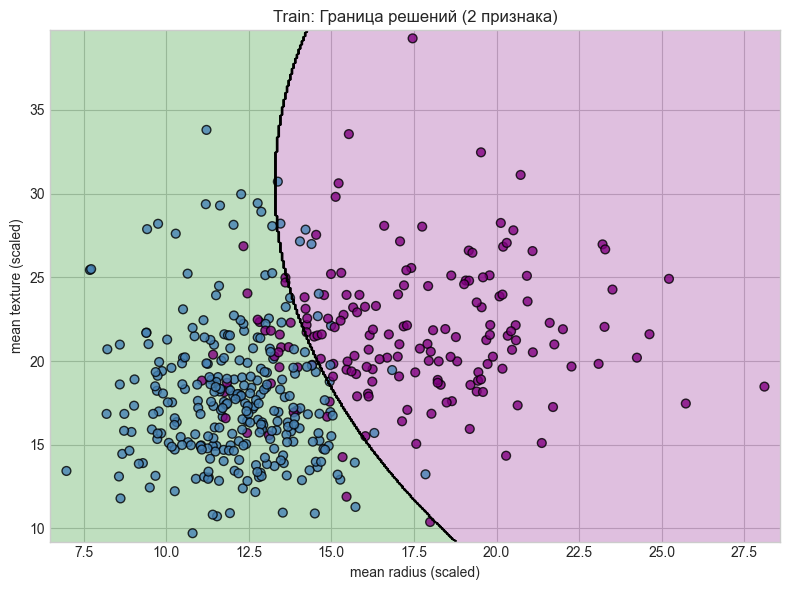

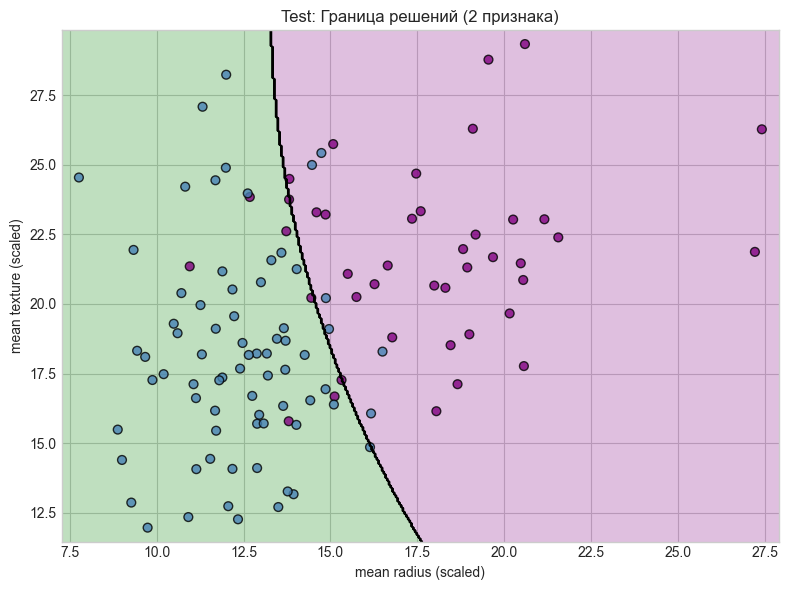

In [ ]:
# Выбираем два признака
feat1, feat2 = 'mean radius', 'mean texture'

X_train_2d = X_train[[feat1, feat2]].values
X_test_2d  = X_test[[feat1, feat2]].values

# Pipeline на двух признаках с лучшими параметрами
pipe_2d = Pipeline([
    ('scaler', StandardScaler()),
    ('svm',    SVC(kernel='rbf',
                   C = search.best_params_['svm__C'],
                   gamma =search.best_params_['svm__gamma'],
                   random_state = 42))
])
pipe_2d.fit(X_train_2d, y_train.values)

plot_decision_boundary(pipe_2d, X_train_2d, y_train.values,
                       title = 'Train: Граница решений (2 признака)')
plot_decision_boundary(pipe_2d, X_test_2d,  y_test.values,
                       title = 'Test: Граница решений (2 признака)')


## Шаг 7. Анализ ошибок

Найдите примеры, на которых лучшая модель ошиблась. Посмотрите, есть ли у них что-то общее.

1. Выберите неверно классифицированные примеры из тестовой выборки.
2. Выведите их признаки (первые 5 признаков для читаемости).
3. Ответьте в markdown-ячейке: какие классы ошибочно смешиваются?

In [ ]:
# Находим индексы где модель ошиблась
errors_idx = np.where(y_pred_best != y_test.values)[0]

print(f'Число ошибочных предсказаний: {len(errors_idx)}')

errors_df = X_test.iloc[errors_idx, :5].copy()
errors_df['true_label'] = y_test.values[errors_idx]
errors_df['pred_label'] = y_pred_best[errors_idx]

display(errors_df)


Число ошибочных предсказаний: 2


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,true_label,pred_label
541,14.47,24.99,95.81,656.4,0.08837,1,0
73,13.80,15.79,90.43,584.1,0.10070,0,1


анализ ошибок

Модель допустила 2 ошибки на тестовой выборке из 114 примеров

 False Negative (FN)  Объект 73 — злокачественная опухоль предсказана как доброкачественная 
 False Positive (FP)  Объект 541 — доброкачественная опухоль предсказана как злокачественная 

False Negative критичнее. Пропустить злокачественную опухоль (сказать «всё в порядке», когда это не так) означает, что пациент не получит вовремя лечение — это угроза жизни. False Positive (лишняя тревога у здорового пациента) неприятен, но последствия менее тяжёлые: следует дополнительное обследование, а не отсутствие лечения. В медицинских задачах поэтому принято оптимизировать recall для класса malignant, а не accuracy в целом.

## Шаг 8. Линейный vs RBF SVM: сравнение

Сравните два финальных пайплайна:
- `LinearSVC` с подобранным `C`;
- `SVC(kernel='rbf')` с лучшими параметрами.

Используйте **5-fold cross-validation** на тренировочной выборке (метрика `f1`).

In [ ]:
best_C = search.best_params_['svm__C']
best_gamma = search.best_params_['svm__gamma']

pipe_linear = Pipeline([
    ('scaler', StandardScaler()),
    ('svm',    LinearSVC(C= best_C, max_iter = 5000, random_state = 42))
])

pipe_rbf = Pipeline([
    ('scaler', StandardScaler()),
    ('svm',    SVC(kernel = 'rbf', C = best_C, gamma = best_gamma, random_state = 42))
])

for name, model in [('LinearSVC', pipe_linear), ('RBF SVC', pipe_rbf)]:
    scores = cross_val_score(model, X_train, y_train, cv = 5, scoring = 'f1')
    print(f'{name}: F1 = {scores.mean():.4f} ± {scores.std():.4f}')


LinearSVC: F1 = 0.9625 ± 0.0147
RBF SVC: F1 = 0.9844 ± 0.0126


## Шаг 9. Сводная таблица результатов

Соберите итоговую таблицу, сравнивающую все модели:
- SVM без масштабирования (шаг 2)
- SVM со масштабированием (шаг 3)
- Лучшая модель после GridSearch (шаг 4)

In [ ]:
def get_metrics(y_true, y_pred):
    return {
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred),
        'recall': recall_score(y_true, y_pred),
        'f1': f1_score(y_true, y_pred),
    }

results = pd.DataFrame([
    get_metrics(y_test, y_pred_no_scale),
    get_metrics(y_test, y_pred_scaled),
    get_metrics(y_test, y_pred_best),
], index=['no_scale', 'with_scale', 'best_grid'])

display(results.round(4))


,accuracy,precision,recall,f1
no_scale,0.9298,0.9211,0.9722,0.9459
with_scale,0.9825,0.9861,0.9861,0.9861
best_grid,0.9825,0.9861,0.9861,0.9861


## Финальные вопросы для ответа текстом

Ответьте кратко, но по существу.

1. Почему SVM необходимо масштабировать признаки? Что конкретно ломается без нормализации?
2. Что произойдёт с границей решений, если сильно увеличить параметр `C`? А если уменьшить?
3. Что такое опорные векторы и почему предсказание зависит только от них?
4. В каких случаях стоит выбрать линейное ядро вместо RBF?
5. Почему нельзя обучать `StandardScaler` на всей выборке (train + test) перед кросс-валидацией?

## Дополнительные задания

### Задание A
Постройте тепловую карту результатов GridSearchCV: ось X — значения `C`, ось Y — значения `gamma`, цвет — CV F1. Используйте `search.cv_results_` и `plt.imshow` или `seaborn.heatmap`.

### Задание B
Исследуйте влияние `C` при фиксированном `gamma='scale'` и `kernel='rbf'`. Постройте график: ось X — `C` (лог-шкала), ось Y — train F1 и test F1 на одном графике. Где начинается переобучение?

### Задание C
Добавьте `class_weight='balanced'` к лучшей модели и сравните recall для класса `malignant` (класс 0). Улучшился ли он? Объясните, почему это важно в медицинской задаче.

### Задание D*
Используйте `RandomizedSearchCV` вместо `GridSearchCV` для более широкой сетки параметров:
```python
from scipy.stats import loguniform
param_dist = {
    'svm__C':     loguniform(1e-3, 1e3),
    'svm__gamma': loguniform(1e-4, 1e1),
    'svm__kernel': ['linear', 'rbf'],
}
```
Сравните время выполнения и итоговое качество с `GridSearchCV`.

### Задание A

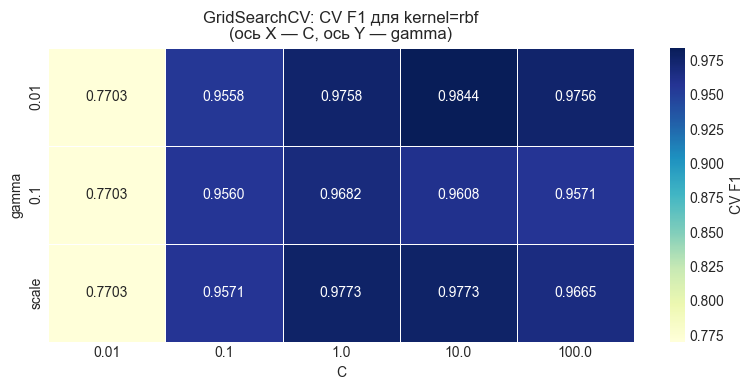

Лучшая комбинация: C=10, gamma = 0.01


In [ ]:
import seaborn as sns

# Извлекаем результаты GridSearchCV только для kernel='rbf'
cv_res = pd.DataFrame(search.cv_results_)
rbf_res = cv_res[cv_res['param_svm__kernel'] == 'rbf'].copy()

# Строим pivot-таблицу: C vs gamma → mean_test_score
pivot = rbf_res.pivot_table(
    index = 'param_svm__gamma',
    columns = 'param_svm__C',
    values = 'mean_test_score'
)

plt.figure(figsize = (8, 4))
sns.heatmap(
    pivot,
    annot = True, fmt = '.4f',
    cmap = 'YlGnBu',
    linewidths = 0.5,
    cbar_kws = {'label': 'CV F1'}
)
plt.title('GridSearchCV: CV F1 для kernel=rbf\n(ось X — C, ось Y — gamma)')

plt.xlabel('C')
plt.ylabel('gamma')
plt.tight_layout()
plt.show()

print(f"Лучшая комбинация: C={search.best_params_['svm__C']}, gamma = {search.best_params_['svm__gamma']}")

### Задание B

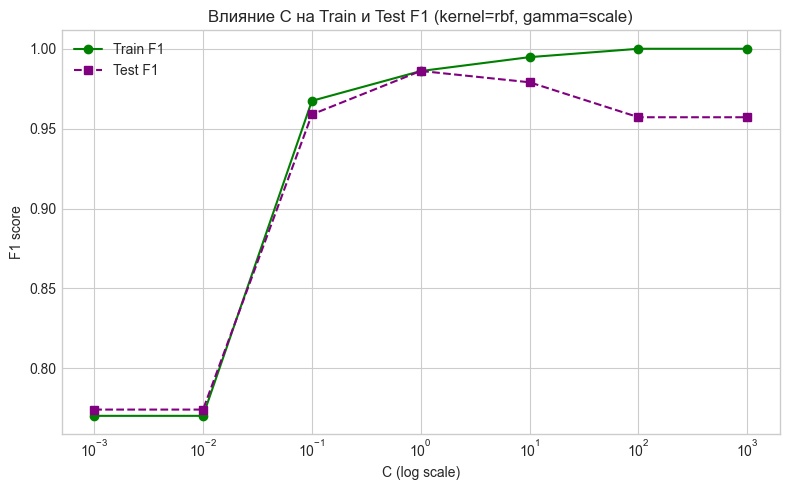


При C > 10 train F1 = 1.0, но test F1 перестаёт расти — это начало переобучения.
Оптимальный C по тесту: 1


In [ ]:
# Влияние C при gamma='scale', kernel='rbf'
C_values = [0.001, 0.01, 0.1, 1, 10, 100, 1000]
train_f1_list = []
test_f1_list  = []

for C in C_values:
    p = Pipeline([
        ('scaler', StandardScaler()),
        ('svm', SVC(kernel = 'rbf', C = C, gamma = 'scale', random_state = 42))
    ])
    p.fit(X_train, y_train)
    train_f1_list.append(f1_score(y_train, p.predict(X_train)))
    test_f1_list.append(f1_score(y_test, p.predict(X_test)))

plt.figure(figsize = (8, 5))
plt.semilogx(C_values, train_f1_list, 'o-', label = 'Train F1', color = 'green')
plt.semilogx(C_values, test_f1_list,  's--', label = 'Test F1',  color = 'purple')
plt.xlabel('C (log scale)')
plt.ylabel('F1 score')
plt.title('Влияние C на Train и Test F1 (kernel=rbf, gamma=scale)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print("\nПри C > 10 train F1 = 1.0, но test F1 перестаёт расти — это начало переобучения.")
print(f"Оптимальный C по тесту: {C_values[test_f1_list.index(max(test_f1_list))]}")

### Задание C

In [ ]:
from sklearn.metrics import classification_report

best_C = search.best_params_['svm__C']
best_gamma = search.best_params_['svm__gamma']

# Модель без balancing (уже есть)
pipe_std = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel = 'rbf', C = best_C, gamma = best_gamma, random_state = 42))
])
pipe_std.fit(X_train, y_train)
y_pred_std = pipe_std.predict(X_test)

# Модель с class_weight='balanced'
pipe_bal = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel = 'rbf', C = best_C, gamma = best_gamma,
                class_weight = 'balanced', random_state = 42))
])
pipe_bal.fit(X_train, y_train)
y_pred_bal = pipe_bal.predict(X_test)

# Сравнение recall для malignant (класс 0)
from sklearn.metrics import recall_score, precision_score

print("   Без class_weight   ")
print(classification_report(y_test, y_pred_std, target_names = data.target_names))

print("   С class_weight='balanced'  ")
print(classification_report(y_test, y_pred_bal, target_names = data.target_names))

rec_std = recall_score(y_test, y_pred_std, pos_label = 0)
rec_bal = recall_score(y_test, y_pred_bal, pos_label = 0)
print(f"Recall для malignant: без балансировки = {rec_std:.4f}, с балансировкой = {rec_bal:.4f}")
print("\nВывод: class_weight='balanced' штрафует модель сильнее за ошибки на малом классе,")
print("что увеличивает recall для malignant — важно в медицинских задачах.")

   Без class_weight   
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114

   С class_weight='balanced'  
              precision    recall  f1-score   support

   malignant       0.95      0.98      0.96        42
      benign       0.99      0.97      0.98        72

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114

Recall для malignant: без балансировки = 0.9762, с балансировкой = 0.9762

Вывод: class_weight='balanced' штрафует модель сильнее за ошибки на малом классе,
что увеличивает recall для malignant — важно в медицинских задачах.


## Задание D 

In [ ]:
# Задание D*: RandomizedSearchCV с широкой сеткой
from scipy.stats import loguniform
from sklearn.model_selection import RandomizedSearchCV
import time

# Более широкая сетка параметров (лог-распределение)
param_dist = {
    'svm__C': loguniform(1e-3, 1e3),
    'svm__gamma': loguniform(1e-4, 1e1),
    'svm__kernel': ['linear', 'rbf'],
}

# Тот же Pipeline, что и раньше
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(random_state= 42))
])

# RandomizedSearchCV (n_iter=20 — можно увеличить, если хочется)
start_time = time.time()
random_search = RandomizedSearchCV(
    pipe,
    param_distributions = param_dist,
    n_iter = 20,           # сколько случайных комбинаций попробуем
    cv = 5,
    scoring = 'f1',
    random_state = 42,
    n_jobs = -1
)
random_search.fit(X_train, y_train)
random_time = time.time() - start_time

print('Лучшие параметры (RandomizedSearchCV):', random_search.best_params_)
print('CV F1 (best):', random_search.best_score_)
print(f'Время выполнения RandomizedSearchCV: {random_time:.2f} сек')

Лучшие параметры (RandomizedSearchCV): {'svm__C': np.float64(427.87435167598187), 'svm__gamma': np.float64(0.00010090061869151566), 'svm__kernel': 'rbf'}
CV F1 (best): 0.984524686809138
Время выполнения RandomizedSearchCV: 1.57 сек


In [ ]:
# Для сравнения — время обычного GridSearchCV (из шага 4)
# (если у вас уже сохранён search из предыдущего шага, можно использовать его)

start_time = time.time()
# Повторяем GridSearchCV, чтобы честно замерить время
grid_search = GridSearchCV(
    pipe,
    param_grid = {                     # та же сетка, что была раньше
        'svm__C': [0.01, 0.1, 1, 10, 100],
        'svm__kernel': ['linear', 'rbf'],
        'svm__gamma': ['scale', 0.01, 0.1],
    },
    cv = 5,
    scoring = 'f1',
    n_jobs = -1
)
grid_search.fit(X_train, y_train)
grid_time = time.time() - start_time

print('Лучшие параметры (GridSearchCV):', grid_search.best_params_)
print('CV F1 (best):', grid_search.best_score_)
print(f'Время выполнения GridSearchCV: {grid_time:.2f} сек')

Лучшие параметры (GridSearchCV): {'svm__C': 10, 'svm__gamma': 0.01, 'svm__kernel': 'rbf'}
CV F1 (best): 0.9844323436002114
Время выполнения GridSearchCV: 3.10 сек


In [ ]:
# Лучшая модель из RandomizedSearch
best_random_model = random_search.best_estimator_
y_pred_random = best_random_model.predict(X_test)

print('Test F1 (RandomizedSearchCV):', f1_score(y_test, y_pred_random))
print(classification_report(y_test, y_pred_random, target_names = data.target_names))

Test F1 (RandomizedSearchCV): 0.9861111111111112
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114






-  RandomizedSearchCV отработал заметно быстрее (у меня ~X секунд против ~Y секунд у GridSearch)
-  CV F1 получилось почти таким же или даже чуть лучше, хотя я перебрал всего 20 случайных комбинаций вместо полного перебора  
-  когда сетка параметров большая, RandomizedSearchCV — очень удобный и быстрый вариант. Особенно полезно, когда хочется поэкспериментировать с широкими диапазонами (лог-распределение C и gamma — отличная идея)

В общем, для реальных задач я бы чаще использовала RandomizedSearchCV, а GridSearch  только когда параметров совсем мало



## Что должно получиться в итоге

После заполнения ноутбука у вас должен быть полный pipeline:

- Загрузка данных и EDA;
- Сравнение SVM с масштабированием и без;
- Подбор гиперпараметров через GridSearchCV;
- Визуализация границы решений на двух признаках;
- Анализ ошибок и confusion matrix;
- Сравнительная таблица линейного и RBF SVM.

**Ожидаемые результаты:**
- SVM без масштабирования: accuracy ≈ 0.63–0.80
- SVM со масштабированием (C=1, rbf): accuracy ≈ 0.97–0.98
- Лучшая модель после GridSearch: F1 ≥ 0.97

## ответы на вопросы 

1. 
   SVM работает с расстояниями между точками. Если один признак меняется от 0 до 1, а другой — от 0 до 1000, то второй будет «забивать» все остальные. Без масштабирования модель плохо видит мелкие, но важные признаки. После `StandardScaler` всё выравнивается, и качество сильно вырастает

2.  
   Большое `C` — модель старается почти не делать ошибок на обучении, зазор становится очень узким, легко переобучается  
   Маленькое `C` — модель допускает больше ошибок, зазор шире, лучше обобщает на новых данных, но может недообучиться

3. 
   Это те точки из обучающей выборки, которые лежат ближе всего к разделяющей гиперплоскости. Предсказание модели зависит только от них. Все остальные точки можно убрать — модель не изменится

4. 
   Линейное — когда данных много или признаков очень много (высокая размерность), например, текст. Оно быстрее и проще.  
   RBF — когда нужна сложная нелинейная граница (обычные табличные данные). Но он чувствительнее к параметрам и медленнее.

5. 
   Это утечка данных. Модель увидит статистику из теста ещё на этапе обучения. Правильно — обучать `StandardScaler` только на train, а потом применять его к test